# Chroma VectorDB


## 1. Chroma란?
Chroma는 오픈소스 벡터 데이터베이스로, 임베딩 벡터를 효율적으로 저장하고 검색할 수 있게 해주는 도구입니다.


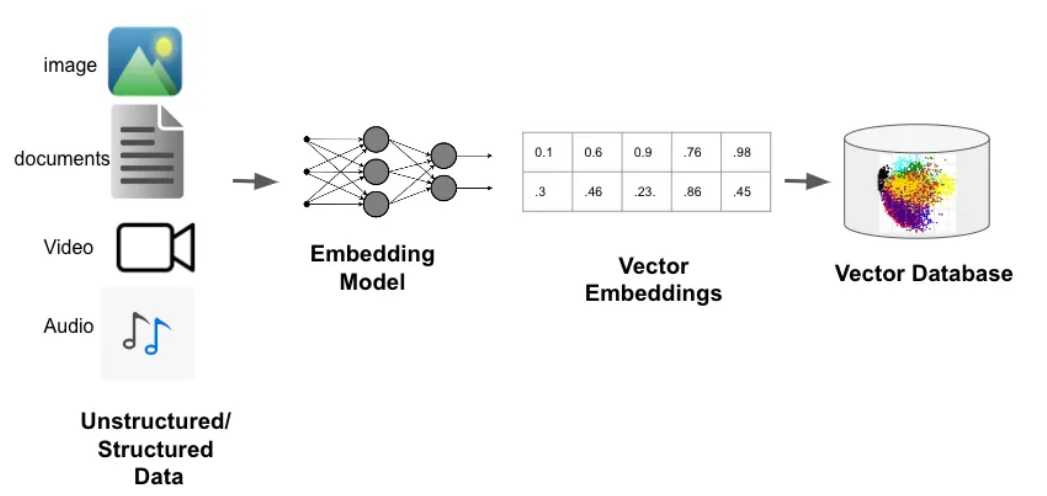

### 주요 특징
- **간단한 설치**: pip install로 쉽게 설치 가능
- **메모리 기반**: 기본적으로 메모리에서 동작하여 빠른 속도
- **영구 저장**: 디스크에 데이터를 저장하여 재시작 후에도 데이터 유지 가능
- **LangChain 통합**: LangChain과 완벽하게 통합되어 RAG 시스템 구축에 최적화


### 사용 사례
- RAG (Retrieval-Augmented Generation) 시스템
- 의미 기반 문서 검색
- 유사도 기반 추천 시스템
- 질문 답변 시스템


## 2. Chroma 클라이언트 생성

Chroma를 사용하기 위해 클라이언트를 생성하는 방법을 알아보겠습니다.


### HTTP 클라이언트 (원격 서버 사용시)
```python
http_client = chromadb.HttpClient(host="localhost", port=8000)
```

### 메모리 기반 클라이언트 (기본)

In [1]:
import chromadb

client = chromadb.Client()

### 영구 저장을 위한 클라이언트

In [2]:
persistent_client = chromadb.PersistentClient(
    path="./chroma_db" # 영구 저장 경로 지정
)


## 3. 컬렉션 생성 및 관리

Chroma에서 데이터를 저장하기 위한 컬렉션을 생성하고 관리하는 방법을 알아보겠습니다.


### 컬렉션 생성

In [3]:
collection = client.create_collection(
    name="my_documents", # 컬렉션 이름
    metadata={"hnsw:space": "cosine"}  # 코사인 유사도 사용
)

### 기존 컬렉션 가져오기

In [4]:
collection = client.get_collection(
    name="my_documents")


### 모든 컬렉션 목록 확인

In [5]:
collections = client.list_collections()
print("생성된 컬렉션:", [c.name for c in collections])

생성된 컬렉션: ['my_documents']


### 컬렉션 삭제

In [6]:
client.delete_collection(name="my_documents")

# 검증하기
collections = client.list_collections()
print("생성된 컬렉션:", [c.name for c in collections])

생성된 컬렉션: []


## 4. 데이터 추가 및 검색

컬렉션에 문서를 추가하고 검색하는 기본적인 방법을 알아보겠습니다.


### 컬렉션 생성

In [7]:
collection = client.create_collection(
    name="my_documents", # 컬렉션 이름
    metadata={"hnsw:space": "cosine"}  # 코사인 유사도 사용
)

### 데이터 정의 

In [8]:
# 샘플 문서 데이터
documents = [
    "인공지능은 인간의 지능을 모방하는 기술입니다.",
    "머신러닝은 데이터로부터 패턴을 학습하는 AI의 한 분야입니다.",
    "딥러닝은 신경망을 사용하는 머신러닝의 하위 분야입니다.",
    "자연어처리는 컴퓨터가 인간의 언어를 이해하고 생성하는 기술입니다."
]

# 문서 ID와 메타데이터
ids = ["doc1", "doc2", "doc3", "doc4"]
metadatas = [
    {"category": "AI", "topic": "기본개념"},
    {"category": "ML", "topic": "학습방법"},
    {"category": "DL", "topic": "신경망"},
    {"category": "NLP", "topic": "언어처리"}
]

### 컬렉션에 문서 추가

In [9]:
# 컬렉션에 문서 추가
collection.add(
    documents=documents,
    ids=ids,
    metadatas=metadatas
)

print("문서가 성공적으로 추가되었습니다.")


C:\Users\Playdata\.cache\chroma\onnx_models\all-MiniLM-L6-v2\onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:13<00:00, 6.18MiB/s]  


문서가 성공적으로 추가되었습니다.


### 기본 검색 (문서로 검색)

In [10]:
results = collection.query(
    query_texts=["신경망에 대해 알려주세요"], # 검색할 쿼리
    n_results=2 # 상위 2개 결과 반환
)

print("검색 결과:")
for i, doc in enumerate(results['documents'][0]):
    print(f"{i+1}. {doc}")
    print(f"   거리: {results['distances'][0][i]}")
    print(f"   ID: {results['ids'][0][i]}")

검색 결과:
1. 자연어처리는 컴퓨터가 인간의 언어를 이해하고 생성하는 기술입니다.
   거리: 0.2934751510620117
   ID: doc4
2. 딥러닝은 신경망을 사용하는 머신러닝의 하위 분야입니다.
   거리: 0.335061252117157
   ID: doc3


### 메타데이터 필터링 검색

In [17]:
filtered_results = collection.query(
    query_texts=["인공지능 기술"],
    n_results=2,
    where={"category": "AI"}  # AI 카테고리만 검색
)

print("필터링된 검색 결과:")
for doc in filtered_results['documents'][0]:
    print(f"- {doc}")


필터링된 검색 결과:
- 인공지능은 인간의 지능을 모방하는 기술입니다.


## 5. 성능 최적화 팁

Chroma를 효율적으로 사용하기 위한 성능 최적화 방법들을 알아보겠습니다.

### 배치 처리로 대량 데이터 추가

In [12]:
def add_documents_in_batches(vectorstore, documents, batch_size=100):
    """문서를 배치 단위로 나누어 추가"""
    for i in range(0, len(documents), batch_size): # 0부터 문서 길이까지 batch_size 간격으로
        batch = documents[i:i + batch_size] # 배치 생성
        vectorstore.add_documents(batch) # 배치 추가
        print(f"배치 {i//batch_size + 1} 완료: {len(batch)}개 문서 추가")
        

### 인덱스 최적화 설정

In [13]:
optimized_client = chromadb.PersistentClient(
    path="./optimized_chroma", # 영구 저장 경로 지정
    settings=chromadb.Settings(
        anonymized_telemetry=False, # 사용자 데이터 비익명화 설정
        allow_reset=True # 기존 데이터베이스 초기화 허용
    )
)


### 메모리 사용량 모니터링

In [14]:
import psutil
import os

def check_memory_usage():
    process = psutil.Process(os.getpid())
    memory_mb = process.memory_info().rss / 1024 / 1024
    print(f"현재 메모리 사용량: {memory_mb:.2f} MB")

check_memory_usage()

현재 메모리 사용량: 192.62 MB


### 컬렉션 정리

In [15]:
def cleanup_collections(client):
    """사용하지 않는 컬렉션 정리"""
    collections = client.list_collections() # 모든 컬렉션 조회

    for collection in collections: # 각 컬렉션에 대해
        print(f"컬렉션 이름: {collection.name}, 문서 수: {collection.count()}")
        if collection.count() == 0: # 문서 수가 0이면
            client.delete_collection(collection.name) # 컬렉션 삭제
            print(f"빈 컬렉션 삭제: {collection.name}")

print("성능 최적화 설정이 완료되었습니다.")


성능 최적화 설정이 완료되었습니다.
